In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=20
    num_feat_binary_interaction = 20
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    num_feat_binary_interaction = 20
    print("Full run mode")



Full run mode


In [3]:
data_prefix = '../data_curation/processed_data/'

if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0.261785,1,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.730914,1,COc1cc(OC)cc(c1C#N)OC,Test
17217,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,7,0,0.596953,1,OCCCCCCCCCCc1ccccc1,Test
17218,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0.439796,1,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test


In [4]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(12054, 388)


,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5
count,12054.0,12054.0,12054.0,12054.00000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,...,12054.000000,12054.000000,12054.00000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000
mean,0.0,0.0,0.0,0.12220,0.276755,0.189398,0.163016,0.156131,0.289945,0.187573,...,0.011283,0.005807,0.00307,0.016592,0.000913,0.017339,0.391322,0.022648,0.586909,0.978679
std,0.0,0.0,0.0,0.32753,0.447413,0.391840,0.369396,0.362994,0.453756,0.390387,...,0.108719,0.084270,0.05532,0.129676,0.037545,0.139149,2.300519,0.152094,0.164722,0.144457
min,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034615,0.000000
25%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.485905,1.000000
50%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600263,1.000000
75%,0.0,0.0,0.0,0.00000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.705439,1.000000
max,0.0,0.0,0.0,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,4.000000,1.00000,2.000000,2.000000,3.000000,41.000000,2.000000,0.945893,1.000000


In [5]:
def feature_engineering_workflow(data_type):

    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data_with_features_train.drop(columns=['SMILES', 'MP', 'Type', 'Ro5'], axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")

    # Subset data based on data_type
    if data_type == 'Ro5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 1].reset_index(drop=True)
    if data_type == 'bRo5':
        data = data_with_features_train[data_with_features_train['Ro5'] == 0].reset_index(drop=True)
    print(f"Processing {data_type} dataset with shape: {data.shape}")
    print()

    # Standardize features
    df_X_scaled = hf.standardize_features(data = data, all_feature_cols=all_feature_cols, scaler_path= data_prefix + f'scaler_{data_type}.pkl', fit=True) 
    print()


    # Reduce features by variance threshold
    df_X_variance = hf.reduce_features_by_variance(df_X_scaled, variance_threshold=0.01)
    print()

    def RFE_workflow(df_X_variance, round):
        print()
        print(f'RFE feature selection: Round {round}:')
        # Reduce features by RFE
        RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
        print()

        # Plot RFE results
        hf.RFE_plot(RFE_results, tolerance)
        # Pickle save the RFE_results
        with open(data_prefix + f'RFE_results_{data_type}_{round}.pkl', 'wb') as f:
            pickle.dump(RFE_results, f)

        df_X_RFE = df_X_variance[RFE_results['best_features']]

        return df_X_RFE, RFE_results

    # First round of RFE
    df_X_RFE, RFE_results_1 = RFE_workflow(df_X_variance, 1)

    # Feature binary interactions
    df_X_interaction = hf.feature_interaction(df_X_RFE, top_n_features=num_feat_binary_interaction)

    # Second round of RFE
    df_X_final, RFE_results_2 = RFE_workflow(df_X_interaction, 2)


    

    return df_X_scaled, df_X_variance, RFE_results_1, df_X_RFE, RFE_results_2, df_X_final

Total number of features: 384
Processing Ro5 dataset with shape: (11797, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_Ro5.pkl
✓ Standardization complete. Shape: (11797, 384)

Original features: 384
Removed features: 15
Remaining features: 369


RFE feature selection: Round 1:


RFE Feature Selection:   1%|▏         | 1/74 iteration

Iteration 0/74 | Features: 364 | RMSE: 37.4200 ± 1.2227 | Removed: [MACCS_16, MACCS_164, MACCS_40, MACCS_44, RDKit_fr_oxazole]


RFE Feature Selection:  15%|█▍        | 11/74 iteration

Iteration 10/74 | Features: 314 | RMSE: 37.4135 ± 1.1809 | Removed: [MACCS_49, MACCS_55, MACCS_60, MACCS_71, RDKit_fr_thiophene]


...

Iteration 60/74 | Features: 64 | RMSE: 37.7896 ± 1.3336 | Removed: [RDKit_NOCount, RDKit_PEOE_VSA10, RDKit_PEOE_VSA12, RDKit_PEOE_VSA13, RDKit_SMR_VSA5]


RFE Feature Selection:  96%|█████████▌| 71/74 iteration

Iteration 70/74 | Features: 14 | RMSE: 43.7825 ± 1.0390 | Removed: [MACCS_101, MACCS_98, RDKit_FractionCSP3, RDKit_NumRotatableBonds, RDKit_SMR_VSA10]


RFE Feature Selection: 100%|██████████| 74/74 iteration



Global best RMSE: 37.1999
Threshold (1.0% tolerance): 37.5719

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 94
  Selected RMSE: 37.2909
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_NumHDonors', 'RDKit_TPSA', 'RDKit_NHOHCount', 'RDKit_fr_Ar_COO']



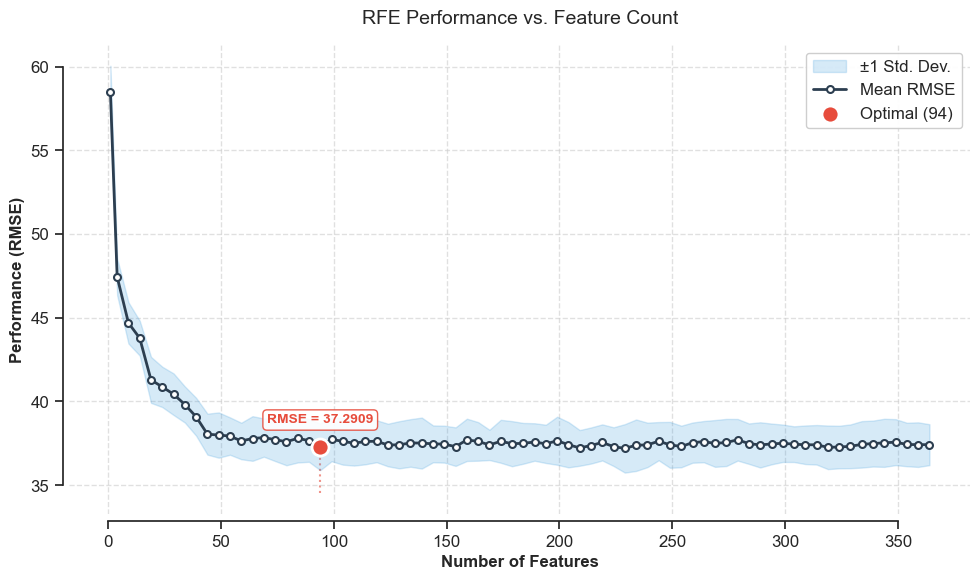

  Optimal Feature Set: 94 features
  Best RMSE: 37.2909
Selecting top 20 features for interaction generation out of 94 available.
Generating 190 interaction features from 20 features...

RFE feature selection: Round 2:


RFE Feature Selection:   2%|▏         | 1/57 iteration

Iteration 0/57 | Features: 279 | RMSE: 37.6290 ± 1.1188 | Removed: [MACCS_105 X RDKit_NumAliphaticRings, MACCS_126 X RDKit_fr_Ar_COO, MACCS_131 X MACCS_165, MACCS_131 X MACCS_43, RDKit_fr_Ar_OH X RDKit_fr_unbrch_alkane]


RFE Feature Selection:  19%|█▉        | 11/57 iteration

Iteration 10/57 | Features: 229 | RMSE: 37.4126 ± 1.2222 | Removed: [RDKit_fr_unbrch_alkane, MACCS_155 X MACCS_165, MACCS_155 X RDKit_fr_Ar_COO, MACCS_43 X RDKit_NumAliphaticRings, RDKit_NumAliphaticRings X RDKit_fr_unbrch_alkane]


...

Iteration 40/57 | Features: 79 | RMSE: 38.0521 ± 1.2991 | Removed: [RDKit_NHOHCount, RDKit_VSA_EState3, MACCS_126 X MACCS_131, MACCS_92 X RDKit_RingCount, RDKit_NumRotatableBonds X RDKit_SlogP_VSA1]


RFE Feature Selection:  89%|████████▉ | 51/57 iteration

Iteration 50/57 | Features: 29 | RMSE: 41.9216 ± 1.2715 | Removed: [RDKit_fr_azide, MACCS_165 X RDKit_FractionCSP3, MACCS_165 X RDKit_TPSA, MACCS_43 X RDKit_BertzCT, RDKit_FractionCSP3 X RDKit_NumHDonors]


RFE Feature Selection: 100%|██████████| 57/57 iteration



Global best RMSE: 37.2111
Threshold (1.0% tolerance): 37.5832

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 99
  Selected RMSE: 37.5248
  Best features (Top 5): ['RDKit_BertzCT X RDKit_fr_Ar_COO', 'RDKit_RingCount X RDKit_fr_Ar_COO', 'RDKit_NumHDonors X RDKit_fr_unbrch_alkane', 'MACCS_105 X RDKit_fr_Ar_COO', 'MACCS_131 X RDKit_RingCount']



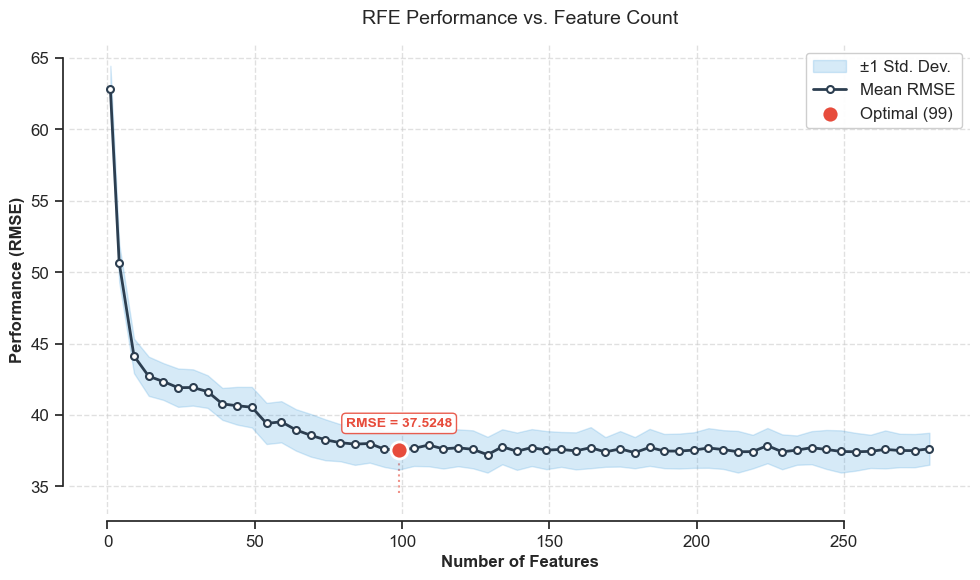

  Optimal Feature Set: 99 features
  Best RMSE: 37.5248


In [6]:
df_Ro5_X_scaled, df_Ro5_X_variance, RFE_results_Ro5_1, df_Ro5_X_RFE, RFE_results_Ro5_2, df_Ro5_X_final = feature_engineering_workflow('Ro5')

Total number of features: 384
Processing bRo5 dataset with shape: (257, 388)

✓ Scaler saved to: ../data_curation/processed_data/scaler_bRo5.pkl
✓ Standardization complete. Shape: (257, 384)

Original features: 384
Removed features: 37
Remaining features: 347


RFE feature selection: Round 1:


RFE Feature Selection:   1%|▏         | 1/70 iteration

Iteration 0/70 | Features: 342 | RMSE: 52.0102 ± 7.3576 | Removed: [MACCS_58, MACCS_59, MACCS_60, MACCS_61, RDKit_SlogP_VSA7]


RFE Feature Selection:  16%|█▌        | 11/70 iteration

Iteration 10/70 | Features: 292 | RMSE: 52.0626 ± 5.9477 | Removed: [MACCS_165, MACCS_20, MACCS_21, MACCS_22, RDKit_fr_pyridine]


...

Iteration 50/70 | Features: 92 | RMSE: 51.1262 ± 8.2801 | Removed: [MACCS_107, MACCS_113, MACCS_145, MACCS_162, RDKit_NumHAcceptors]


RFE Feature Selection:  87%|████████▋ | 61/70 iteration

Iteration 60/70 | Features: 42 | RMSE: 48.7969 ± 6.9699 | Removed: [MACCS_99, RDKit_BCUT2D_MRLOW, RDKit_Chi2n, RDKit_Chi2v, RDKit_PEOE_VSA5]


RFE Feature Selection: 100%|██████████| 70/70 iteration



Global best RMSE: 47.2915
Threshold (1.0% tolerance): 47.7644

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 22
  Selected RMSE: 47.3116
  Best features (Top 5): ['RDKit_RingCount', 'RDKit_TPSA', 'RDKit_FractionCSP3', 'RDKit_VSA_EState1', 'RDKit_NumHeteroatoms']



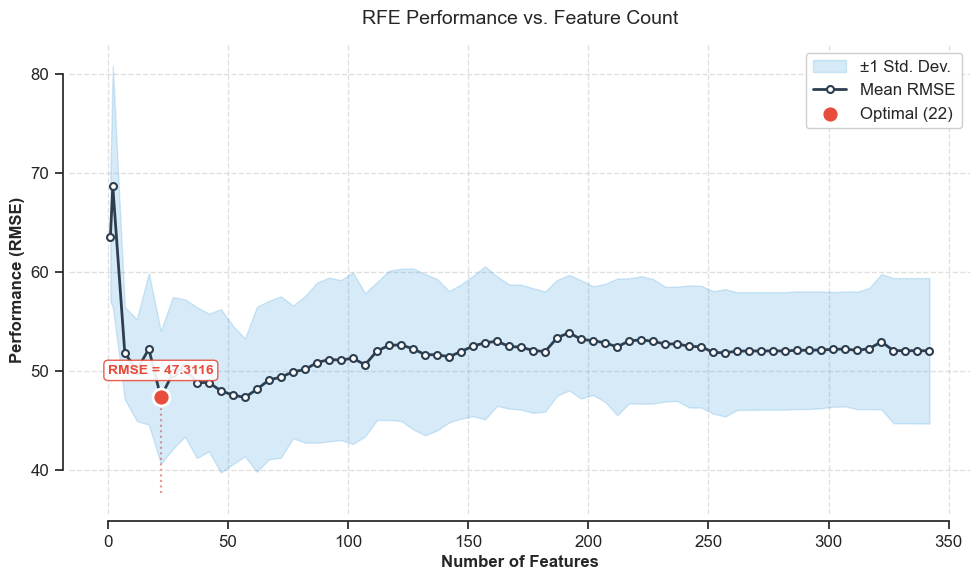

  Optimal Feature Set: 22 features
  Best RMSE: 47.3116
Selecting top 20 features for interaction generation out of 22 available.
Generating 190 interaction features from 20 features...

RFE feature selection: Round 2:


RFE Feature Selection:   2%|▏         | 1/43 iteration

Iteration 0/43 | Features: 207 | RMSE: 47.2381 ± 4.8477 | Removed: [RDKit_NumBridgeheadAtoms, RDKit_FpDensityMorgan3 X RDKit_VSA_EState6, RDKit_NumBridgeheadAtoms X RDKit_RingCount, RDKit_NumBridgeheadAtoms X RDKit_SMR_VSA6, RDKit_NumBridgeheadAtoms X RDKit_VSA_EState6]


RFE Feature Selection:  26%|██▌       | 11/43 iteration

Iteration 10/43 | Features: 157 | RMSE: 48.7155 ± 5.7103 | Removed: [RDKit_LabuteASA X RDKit_MolLogP, RDKit_MolLogP X RDKit_NumRotatableBonds, RDKit_NumBridgeheadAtoms X RDKit_NumHeteroatoms, RDKit_RingCount X RDKit_SMR_VSA10, RDKit_SMR_VSA10 X RDKit_VSA_EState1]


...

Iteration 30/43 | Features: 57 | RMSE: 42.4300 ± 4.0190 | Removed: [RDKit_Chi4v X RDKit_NumBridgeheadAtoms, RDKit_FpDensityMorgan1 X RDKit_SMR_VSA10, RDKit_FpDensityMorgan3 X RDKit_NumBridgeheadAtoms, RDKit_FpDensityMorgan3 X RDKit_VSA_EState1, RDKit_TPSA X RDKit_qed]


RFE Feature Selection:  95%|█████████▌| 41/43 iteration

Iteration 40/43 | Features: 7 | RMSE: 52.4845 ± 4.4761 | Removed: [RDKit_Chi3n, RDKit_Chi3n X RDKit_NumRotatableBonds, RDKit_EState_VSA4 X RDKit_VSA_EState6, RDKit_FpDensityMorgan3 X RDKit_FractionCSP3, RDKit_FractionCSP3 X RDKit_RingCount]


RFE Feature Selection: 100%|██████████| 43/43 iteration


Global best RMSE: 42.4300
Threshold (1.0% tolerance): 42.8543

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 22
  Selected RMSE: 42.7336
  Best features (Top 5): ['RDKit_NumRotatableBonds X RDKit_VSA_EState1', 'RDKit_FractionCSP3 X RDKit_VSA_EState1', 'RDKit_NumRotatableBonds X RDKit_RingCount', 'RDKit_RingCount X RDKit_TPSA', 'RDKit_FractionCSP3 X RDKit_RingCount']



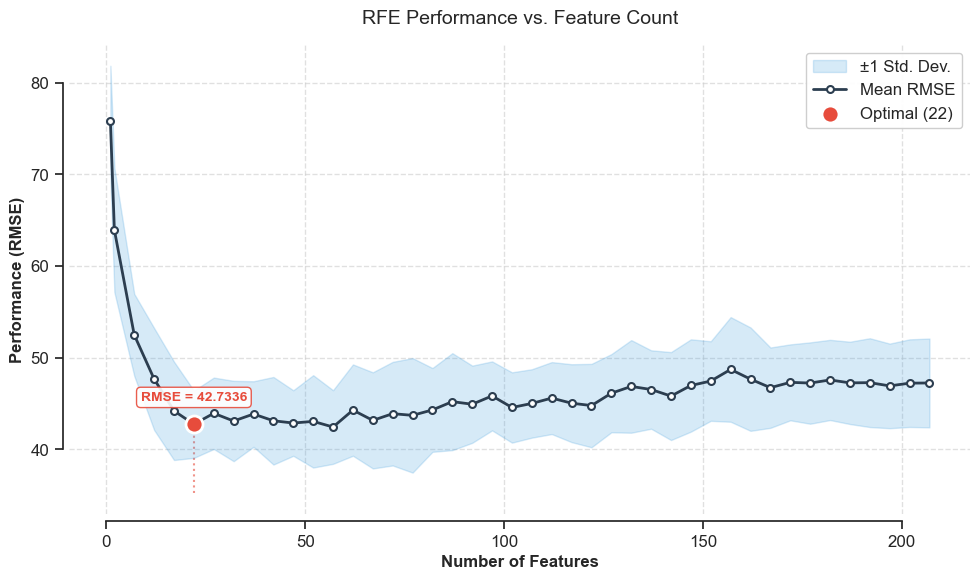

  Optimal Feature Set: 22 features
  Best RMSE: 42.7336


In [7]:
df_H_X_scaled, df_H_X_variance, RFE_results_bRo5_1, df_bRo5_X_RFE, RFE_results_bRo5_2, df_bRo5_X_final = feature_engineering_workflow('bRo5')

In [8]:
selected_features = hf.combine_features(df_Ro5_X_final, df_bRo5_X_final)

Number of features in Ro5 dataset: 99
Number of features in bRo5 dataset: 22
Number of overlapping features: 3
Overlapping features: {'RDKit_TPSA', 'RDKit_RingCount X RDKit_TPSA', 'RDKit_NumRotatableBonds X RDKit_RingCount'}
Total number of combined features: 118


In [9]:
with open(data_prefix + 'selected_feature_list.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

In [10]:
with open(data_prefix + 'selected_feature_list.pkl', 'rb') as f:
    selected_features  = pickle.load(f)

print(selected_features)
print(len(selected_features))

['RDKit_PEOE_VSA3', 'RDKit_NumAliphaticRings X RDKit_SlogP_VSA8', 'RDKit_NHOHCount', 'RDKit_SMR_VSA10 X RDKit_VSA_EState6', 'MACCS_105 X RDKit_NHOHCount', 'MACCS_105 X RDKit_fr_Ar_COO', 'RDKit_FpDensityMorgan1 X RDKit_NumRotatableBonds', 'RDKit_NHOHCount X RDKit_fr_Ar_COO', 'MACCS_131 X RDKit_RingCount', 'RDKit_NHOHCount X RDKit_NumAliphaticRings', 'MACCS_89', 'RDKit_NumHeteroatoms X RDKit_TPSA', 'MACCS_155 X RDKit_Chi3n', 'RDKit_TPSA', 'RDKit_NOCount', 'RDKit_FpDensityMorgan1 X RDKit_FpDensityMorgan3', 'RDKit_VSA_EState3', 'MACCS_126 X RDKit_TPSA', 'RDKit_VSA_EState2', 'RDKit_SlogP_VSA1 X RDKit_fr_Ar_OH', 'MACCS_92 X RDKit_BertzCT', 'RDKit_SMR_VSA9', 'RDKit_BertzCT X RDKit_NumRotatableBonds', 'RDKit_SlogP_VSA1', 'RDKit_BertzCT X RDKit_NumHDonors', 'RDKit_EState_VSA4 X RDKit_VSA_EState6', 'MACCS_121', 'RDKit_NumRotatableBonds X RDKit_TPSA', 'RDKit_FpDensityMorgan3', 'RDKit_NumHeteroatoms X RDKit_NumRotatableBonds', 'RDKit_NHOHCount X RDKit_NumHDonors', 'RDKit_fr_allylic_oxid', 'MACCS_1

# Get the dataset

In [11]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

data_with_features

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0.261785,1,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.730914,1,COc1cc(OC)cc(c1C#N)OC,Test
17217,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,7,0,0.596953,1,OCCCCCCCCCCc1ccccc1,Test
17218,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0.439796,1,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test


In [12]:
df_final = hf.dataset_featurization(data_with_features, selected_features, data_prefix + 'final_dataset')

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'RDKit_{name}'] = [f[i] for f in rdkit_features]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_hel

✓ RDKit: Added 217 features


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_features[f'MACCS_{i}'] = maccs_array[:, i]
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/feature_engineering/feature_engineering_helper.py:65: PerformanceWarning: D

✓ MACCS: Added 167 features
Generating 73536 interaction features from 384 features...
../data_curation/processed_data/final_dataset dataset saved.


In [13]:
df_final = pd.read_parquet(data_prefix + 'final_dataset.parquet')

In [14]:
df_final_scaled = hf.standardize_data(df_final, data_prefix + 'df_final_scaler.pkl')

Number of feature columns to standardize: 118
Scaler saved to ../data_curation/processed_data/df_final_scaler.pkl
